In [1]:
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

ml_client = MLClient.from_config(credential=DefaultAzureCredential())
print(f"Connected to Workspace: {ml_client.workspace_name}")

Found the config file in: /config.json


Connected to Workspace: fraud_detection_project


In [2]:
import pandas as pd

# Helper function to make loading faster
def load_azure_csv(asset_name):
    asset = ml_client.data.get(name=asset_name, version="1")
    return pd.read_csv(asset.path)

# Load Features
X_train_imb = load_azure_csv("X-train-imb")
X_train_smote = load_azure_csv("X-train-smote")
X_test = load_azure_csv("X-test-final")

# Load Labels (and flatten to 1D array)
y_train_imb = load_azure_csv("y-train-imb").values.ravel()
y_train_smote = load_azure_csv("y-train-smote").values.ravel()
y_test = load_azure_csv("y-test-final").values.ravel()

print("All cloud assets loaded successfully!")

Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/mlflow/__init__.py:41: UserWarning: Versions of mlflow (2.7.1) and child packages mlflow-skinny (3.9.0), mlflow-tracing (3.8.1) are different. This may lead to unexpected behavior. Please install the same version of all MLflow packages.
  mlflow.mismatch._check_version_mismatch()
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook 

All cloud assets loaded successfully!


In [3]:
import mlflow

# Point MLflow to Azure ML Workspace
mlflow.set_tracking_uri(ml_client.workspaces.get(ml_client.workspace_name).mlflow_tracking_uri)

# Set the Experiment Name
experiment_name = "fraud-detection-tournament"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='', creation_time=1771958099637, experiment_id='6154cf18-a565-4006-88ec-6e5e4b3c9edc', last_update_time=None, lifecycle_stage='active', name='fraud-detection-tournament', tags={}>

In [10]:
import mlflow
from sklearn.metrics import average_precision_score, recall_score, precision_score, f1_score

mlflow.sklearn.autolog(disable=True)

for scenario_name, (train_x, train_y) in scenarios.items():
    for model_name, model in models.items():
        
        with mlflow.start_run(run_name=f"{model_name}-{scenario_name}"):
            
            print(f"🚀 Training {model_name} on {scenario_name}...", flush=True)
            
            # --- TRAIN ---
            model.fit(train_x, train_y)
            
            # --- PREDICT ---
            probs = model.predict_proba(X_test)[:, 1]
            preds = model.predict(X_test)
            
            # --- CALCULATE METRICS ---
            auprc = average_precision_score(y_test, probs)
            recall = recall_score(y_test, preds)
            precision = precision_score(y_test, preds)
            f1 = f1_score(y_test, preds)
            
            # --- LOG PARAMETERS ---
            mlflow.log_param("Algorithm", model_name)
            mlflow.log_param("Data Strategy", scenario_name)
            
            # --- LOG METRICS ---
            mlflow.log_metric("AUPRC", auprc)
            mlflow.log_metric("Recall", recall)
            mlflow.log_metric("Precision", precision)
            mlflow.log_metric("F1-Score", f1)
            
            print(f"Metrics logged: AUPRC={auprc:.4f}, Recall={recall:.4f}", flush=True)

print("\n--- Tournament Complete! Check the 'Jobs' tab in Azure ML Studio to compare results. ---")

🚀 Training Logistic_Regression on Imbalanced...
Metrics logged: AUPRC=0.7353, Recall=0.6531
🏃 View run Logistic_Regression-Imbalanced at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspaces/fraud_detection_project/#/experiments/6154cf18-a565-4006-88ec-6e5e4b3c9edc/runs/22bcbf78-bd13-403c-943f-05af9994aa71
🧪 View experiment at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspaces/fraud_detection_project/#/experiments/6154cf18-a565-4006-88ec-6e5e4b3c9edc
🚀 Training Random_Forest on Imbalanced...
Metrics logged: AUPRC=0.8675, Recall=0.8265
🏃 View run Random_Forest-Imbalanced at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspac

In [4]:
# 1. Get the Experiment ID by name
experiment = mlflow.get_experiment_by_name("fraud-detection-tournament")

# 2. Search for all runs in this experiment
# This returns a pandas DataFrame automatically!
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

# 3. Clean up the view (Optional)
# MLflow adds many columns (start time, tags, etc.); let's pick the important ones
cols_to_keep = [
    'run_id',
    'params.Algorithm', 
    'params.Data Strategy', 
    'metrics.AUPRC', 
    'metrics.Recall', 
    'metrics.Precision', 
    'metrics.F1-Score'
]

summary_df = runs_df[cols_to_keep].copy()

# Rename columns for a cleaner look
summary_df.columns = ['run_id','Algorithm', 'Data Strategy', 'AUPRC', 'Recall', 'Precision', 'F1-Score']


# Rank by AUPRC descending
ranked_models = summary_df.dropna(subset=['Algorithm']).drop_duplicates(subset=['Algorithm', 'Data Strategy']).sort_values(by='AUPRC', ascending=False).reset_index(drop=True)

# Display the final leaderboard
display(ranked_models)

,run_id,Algorithm,Data Strategy,AUPRC,Recall,Precision,F1-Score
0,14bf20e2-c104-4f54-a571-5ed8e946ce87,Random_Forest,SMOTE,0.880709,0.826531,0.880435,0.852632
1,5a4c7525-5375-47d2-b01a-5abcefcf7d7a,XGBoost,SMOTE,0.871347,0.867347,0.708333,0.779817
2,896becb9-2563-4ccd-becb-c2e307017361,Random_Forest,Imbalanced,0.867538,0.826531,0.952941,0.885246
3,73362a61-24e6-4249-bab3-95e8a842bfa2,XGBoost,Imbalanced,0.804338,0.785714,0.885057,0.832432
4,17fb1b01-ff14-4e41-b8e1-ca3bdf670b4f,Logistic_Regression,Imbalanced,0.735294,0.653061,0.790123,0.715084
5,4654a448-f783-4b3d-8f38-1401d8e5b359,Logistic_Regression,SMOTE,0.727711,0.918367,0.054979,0.103746


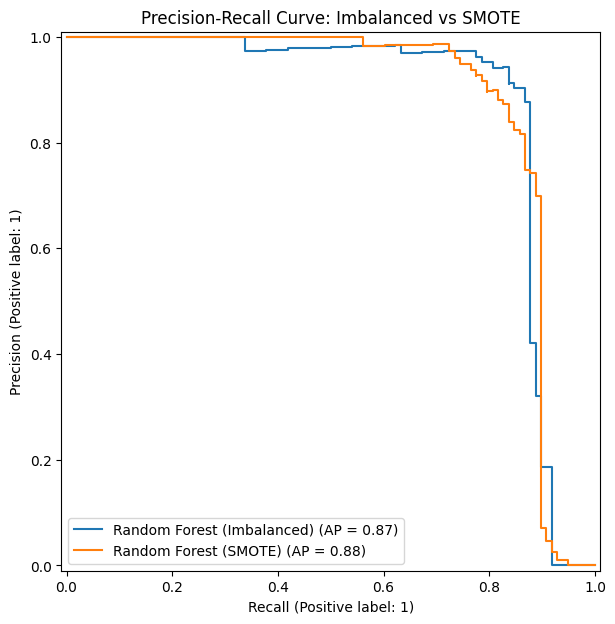

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(10, 7))

# Plot the random forest for both to see the SMOTE impact clearly
for scenario_name, (train_x, train_y) in scenarios.items():
    model = RandomForestClassifier().fit(train_x, train_y)
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax, name=f"Random Forest ({scenario_name})")

plt.title("Precision-Recall Curve: Imbalanced vs SMOTE")
plt.show()

In [62]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

mlflow.set_experiment("RF_hyperparameter_tuning")
mlflow.sklearn.autolog(max_tuning_runs=15, log_models=True)

# Create a pipeline: SMOTE -> Classifier
# This ensures SMOTE only happens on training folds, never on validation
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

# Update your param_dist to include the 'rf__' prefix
param_dist_fast = {
    'rf__n_estimators': [100, 150], 
    'rf__max_depth': [10, 15],
    'rf__min_samples_leaf': [4, 8]
}

random_search_rf = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=5,
    cv=2,
    scoring='average_precision',
    n_jobs=1,
    verbose=3
)

# Use the ORIGINAL training data
random_search_rf.fit(X_train_imb, y_train_imb)

print(f"✅ Best AUPRC Found: {random_search_rf.best_score_:.4f}")
print(f"🏆 Best Params: {random_search_rf.best_params_}")

2026/02/25 16:09:06 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'be4c2a2b-b77a-43ec-b8a9-a995871c4f06', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


Fitting 2 folds for each of 5 candidates, totalling 10 fits
[CV 1/2] END rf__max_depth=20, rf__min_samples_leaf=2, rf__n_estimators=100;, score=0.835 total time= 2.9min
[CV 2/2] END rf__max_depth=20, rf__min_samples_leaf=2, rf__n_estimators=100;, score=0.819 total time= 3.2min
[CV 1/2] END rf__max_depth=None, rf__min_samples_leaf=4, rf__n_estimators=100;, score=0.840 total time= 2.9min
[CV 2/2] END rf__max_depth=None, rf__min_samples_leaf=4, rf__n_estimators=100;, score=0.818 total time= 3.1min
[CV 1/2] END rf__max_depth=10, rf__min_samples_leaf=4, rf__n_estimators=100;, score=0.802 total time= 2.2min
[CV 2/2] END rf__max_depth=10, rf__min_samples_leaf=4, rf__n_estimators=100;, score=0.794 total time= 2.3min
[CV 1/2] END rf__max_depth=10, rf__min_samples_leaf=2, rf__n_estimators=200;, score=0.804 total time= 4.4min
[CV 2/2] END rf__max_depth=10, rf__min_samples_leaf=2, rf__n_estimators=200;, score=0.799 total time= 4.5min
[CV 1/2] END rf__max_depth=10, rf__min_samples_leaf=2, rf__n_est

In [64]:
from xgboost import XGBClassifier

mlflow.set_experiment("XGBoost_hyperparameter_tuning")
mlflow.sklearn.autolog(max_tuning_runs=15, log_models=True)

# 1. Define the XGBoost Pipeline
xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

# 2. Regularization-focused Search Space
# 'reg_alpha' and 'reg_lambda' are the "magic" parameters that stop overfitting
param_dist_xgb = {
    'xgb__n_estimators': [100, 200],
    'xgb__learning_rate': [0.01, 0.1],
    'xgb__max_depth': [3, 6],
    'xgb__reg_alpha': [0, 0.1, 1], 
    'xgb__reg_lambda': [1, 5]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist_xgb,
    n_iter=5, # Keep it small for speed
    cv=2,
    scoring='average_precision',
    n_jobs=-1,
    verbose=3
)

print("Tuning XGBoost...")
random_search_xgb.fit(X_train_imb, y_train_imb)

print(f"Best AUPRC Found: {random_search_xgb.best_score_:.4f}")
print(f"Best Params: {random_search_xgb.best_params_}")

2026/02/25 16:49:44 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost-finetuning' does not exist. Creating a new experiment.
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [16:49:58] WARNING: /__w/xgboost/xgboost/src/l

Tuning XGBoost...
Fitting 2 folds for each of 5 candidates, totalling 10 fits
🏃 View run polite_jelly_4d0zpzy6 at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspaces/fraud_detection_project/#/experiments/f2abaa64-7576-47de-8d16-726ae7e5f309/runs/691c3481-259f-4112-b63e-1938ba9b72c0
🧪 View experiment at: https://uksouth.api.azureml.ms/mlflow/v2.0/subscriptions/86a6ee06-cdec-4f8f-bfc5-0e831cd3e9ca/resourceGroups/uctzyac-rg/providers/Microsoft.MachineLearningServices/workspaces/fraud_detection_project/#/experiments/f2abaa64-7576-47de-8d16-726ae7e5f309


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'xgb__learning_rate': [0.01, 0.1], 'xgb__max_depth': [3, 6], 'xgb__n_estimators': [100, 200], 'xgb__reg_alpha': [0, 0.1, ...], ...}"
,n_iter,5
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,2
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


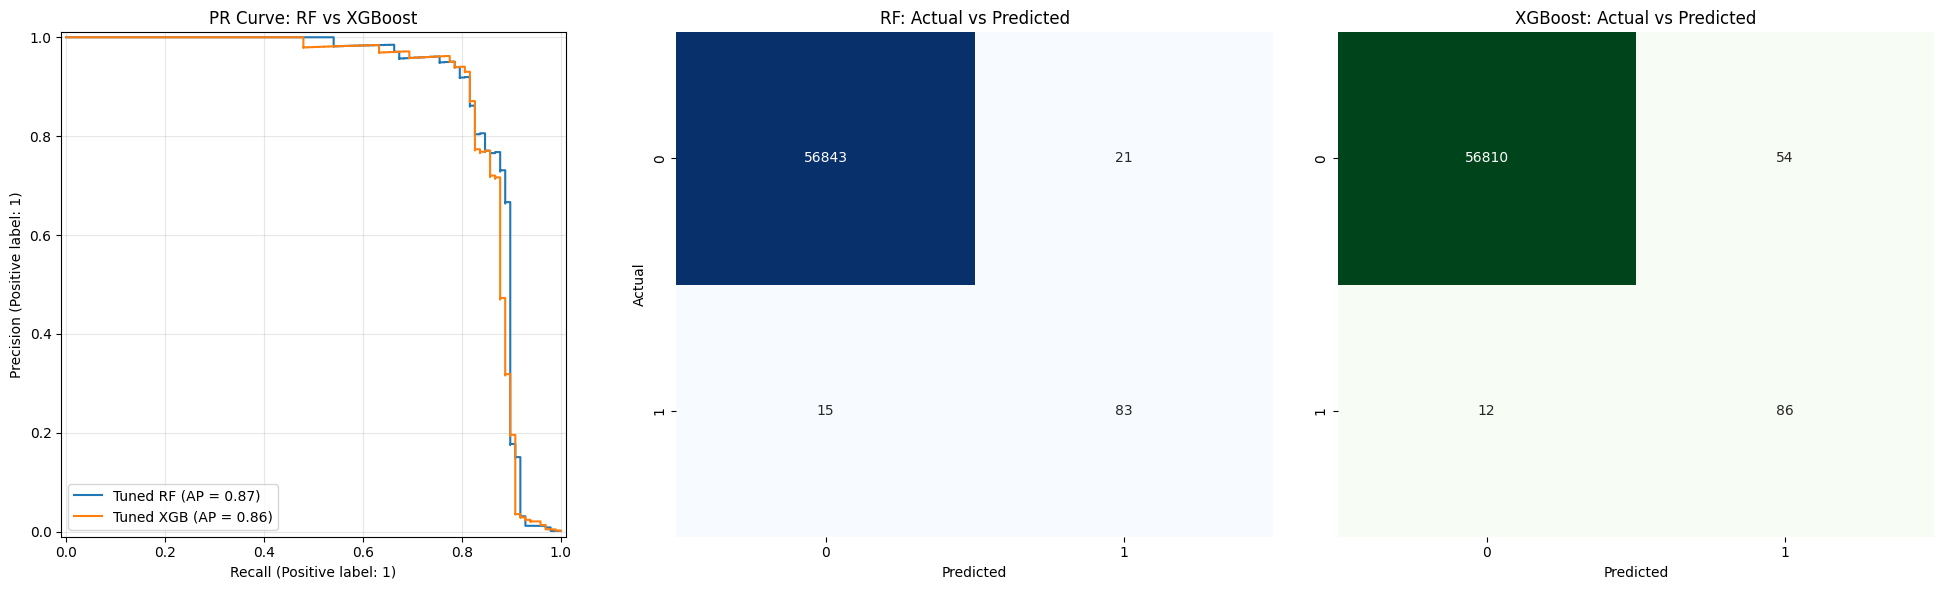

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns

# Extract the best estimators
best_rf = random_search_rf.best_estimator_
best_xgb = random_search_xgb.best_estimator_

# Generate Predictions
rf_probs = best_rf.predict_proba(X_test)[:, 1]
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

# Calculate Final AUPRC Scores
rf_auprc = average_precision_score(y_test, rf_probs)
xgb_auprc = average_precision_score(y_test, xgb_probs)

# Setup the Figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- PANEL 1: Precision-Recall Curve ---
ax1 = axes[0]
PrecisionRecallDisplay.from_estimator(best_rf, X_test, y_test, ax=ax1, name="Tuned RF")
PrecisionRecallDisplay.from_estimator(best_xgb, X_test, y_test, ax=ax1, name="Tuned XGB")
ax1.set_title("PR Curve: RF vs XGBoost")
ax1.grid(True, alpha=0.3)

# --- PANEL 2: Confusion Matrix (RF) ---
y_pred_rf = best_rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title("RF: Actual vs Predicted")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# --- PANEL 3: Confusion Matrix (XGBoost) ---
y_pred_xgb = best_xgb.predict(X_test)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[2], cbar=False)
axes[2].set_title("XGBoost: Actual vs Predicted")
axes[2].set_xlabel("Predicted")

plt.tight_layout()
plt.show()

In [74]:
from azure.ai.ml.entities import Model
from azure.ai.ml.constants import AssetTypes

# 1. Define the model metadata
model_name = "fraud-detection-champion"
model_path = "tuned_rf_champion.pkl" # The file you saved earlier

cloud_model = Model(
    path=model_path,
    type=AssetTypes.CUSTOM_MODEL,
    name=model_name,
    description="Random Forest champion tuned with SMOTE-integrated pipeline.",
    tags={"auprc": "0.84", "algorithm": "RandomForest"}
)

# 2. Register it to the Azure Workspace
ml_client.models.create_or_update(cloud_model)
print(f"Model registered as: {model_name}")

Uploading tuned_rf_champion.pkl (< 1 MB): 100%|██████████| 521k/521k [00:00<00:00, 17.9MB/s]




Model registered as: fraud-detection-champion


In [75]:
from azure.ai.ml.entities import ManagedOnlineEndpoint, ManagedOnlineDeployment

# 1. Create the Endpoint (the URL)
endpoint_name = "fraud-api-endpoint"
endpoint = ManagedOnlineEndpoint(name=endpoint_name, auth_mode="key")
ml_client.online_endpoints.begin_create_or_update(endpoint).result()

# 2. Deploy the Model to that Endpoint
# This takes about 10-15 mins as Azure sets up a small server for you
deployment = ManagedOnlineDeployment(
    name="blue-deployment",
    endpoint_name=endpoint_name,
    model=cloud_model,
    instance_type="Standard_DS2_v2",
    instance_count=1
)
ml_client.online_deployments.begin_create_or_update(deployment).result()

HttpResponseError: (SubscriptionNotRegistered) Resource provider [N/A] isn't registered with Subscription [N/A]. Please see troubleshooting guide, available here: https://aka.ms/register-resource-provider
Code: SubscriptionNotRegistered
Message: Resource provider [N/A] isn't registered with Subscription [N/A]. Please see troubleshooting guide, available here: https://aka.ms/register-resource-provider